In [17]:
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import pickle
import joblib

In [3]:

df1 = pd.read_excel('old.xlsx')  
df2 = pd.read_excel('new.xlsx')

# Получаем список матчей из первой половины года
first_half_matches = df1['Матч'].unique()

# Фильтруем второй датасет
df2_second_half = df2[~df2['Матч'].isin(first_half_matches)]

print(f"Исходно записей в new.xlsx: {len(df2)}")
print(f"Осталось записей после фильтрации: {len(df2_second_half)}")
df2_second_half

Исходно записей в new.xlsx: 575090
Осталось записей после фильтрации: 122101


,Турнир,ИгрокФИО,Амплуа,Команда,Матч,ИндексНаМатч_90,ИгровоеВремя,Данные,КоличествоДействий
125071,Молодежное первенство,Ананьев Иван Алексеевич,DM,ЦСКА Москва-М,Крылья Советов-М 0 : 3 ЦСКА Москва-М (12.09.2025),115.64100,82.5356,Передача ключевая неточная,1
125072,Молодежное первенство,Ананьев Иван Алексеевич,DM,ЦСКА Москва-М,Крылья Советов-М 0 : 3 ЦСКА Москва-М (12.09.2025),115.64100,82.5356,Единоборство вверху в обороне удачное,3
125073,Молодежное первенство,Ананьев Иван Алексеевич,DM,ЦСКА Москва-М,Крылья Советов-М 0 : 3 ЦСКА Москва-М (12.09.2025),115.64100,82.5356,Единоборство вверху в атаке неудачное,1
125074,Молодежное первенство,Ананьев Иван Алексеевич,DM,ЦСКА Москва-М,Крылья Советов-М 0 : 3 ЦСКА Москва-М (12.09.2025),115.64100,82.5356,Борьба за нейтральный мяч неудачная,1
125075,Молодежное первенство,Ананьев Иван Алексеевич,DM,ЦСКА Москва-М,Крылья Советов-М 0 : 3 ЦСКА Москва-М (12.09.2025),115.64100,82.5356,"Эффективность ""+"" Продвижения мяча вперед за с...",2
...,...,...,...,...,...,...,...,...,...
575085,ЮФЛ-3,Левов Фёдор,FB,Локомотив Москва U-16,2010 г.р. 3 : 2 Локомотив Москва U-16 (18.10.2...,14.99481,34.5119,Передача прогрессивная точная,3
575086,ЮФЛ-3,Левов Фёдор,FB,Локомотив Москва U-16,2010 г.р. 3 : 2 Локомотив Москва U-16 (18.10.2...,14.99481,34.5119,Передача в борьбу +,2
575087,ЮФЛ-3,Левов Фёдор,FB,Локомотив Москва U-16,2010 г.р. 3 : 2 Локомотив Москва U-16 (18.10.2...,14.99481,34.5119,Замена,1
575088,ЮФЛ-3,Левов Фёдор,FB,Локомотив Москва U-16,2010 г.р. 3 : 2 Локомотив Москва U-16 (18.10.2...,14.99481,34.5119,Борьба за нейтральный мяч неудачная,1


In [5]:
pivot_df = df2_second_half.pivot_table(
    index=['Турнир', 'ИгрокФИО', 'Амплуа', 'Команда', 'Матч', 'ИндексНаМатч_90', 'ИгровоеВремя'],
    columns='Данные',
    values='КоличествоДействий',
    aggfunc='sum',
    fill_value=0
)

pivot_df = pivot_df.reset_index()

pivot_df.head()

Данные,Турнир,ИгрокФИО,Амплуа,Команда,Матч,ИндексНаМатч_90,ИгровоеВремя,Автогол,Блокировка навеса,Блокировка передачи,...,Удар перехваченный,Участие в голевой атаке,Фол,Фол на игроке,"Эффективность ""+"" Обводки в зоне завершения","Эффективность ""+"" Подбора мяча","Эффективность ""+"" Продвижения мяча вперед за счет дриблинга","Эффективность ""-"" Обводки в зоне завершения","Эффективность ""-"" Подбора мяча","Эффективность ""-"" Продвижения мяча вперед за счет дриблинга"
0,Молодежное первенство,Абдулхаликов Арсений,AM,Динамо-М,Динамо-М 3 : 3 Урал-М (03.10.2025),-21.24792,16.9428,0,0,0,...,0,0,2,0,0,0,0,0,0,0
1,Молодежное первенство,Абдулхаликов Арсений,ST,Динамо-М,Динамо-М 3 : 3 Урал-М (03.10.2025),122.38569,17.3182,0,0,0,...,0,1,0,0,0,1,0,0,0,0
2,Молодежное первенство,Абдулхаликов Арсений,W,Динамо-М,Динамо-М 3 : 3 Урал-М (03.10.2025),112.44546,60.1091,0,0,2,...,0,1,1,0,1,1,0,1,0,1
3,Молодежное первенство,Авраменко Данил,CD,Динамо-М,Динамо-М 0 : 2 Сочи-М (19.09.2025),151.76070,95.2420,0,0,0,...,1,0,0,0,0,7,2,0,3,0
4,Молодежное первенство,Авраменко Данил,CD,Динамо-М,Динамо-М 3 : 3 Урал-М (03.10.2025),139.90653,94.3701,0,0,0,...,0,1,0,0,0,4,2,2,4,1


In [6]:
pivot_df_mp = pivot_df[pivot_df['Турнир'] == 'Молодежное первенство']

pivot_df_1 = pivot_df[pivot_df['Турнир'] == 'ЮФЛ-1']

pivot_df_2 = pivot_df[pivot_df['Турнир'] == 'ЮФЛ-2']

pivot_df_3 = pivot_df[pivot_df['Турнир'] == 'ЮФЛ-3']

In [7]:
# Считаем дисперсию до удаления
variance_index_mp_before = pivot_df_mp['ИндексНаМатч_90'].var()
print(f"Дисперсия до удаления: {variance_index_mp_before}")

threshold1 = -80
threshold = 200

data_delete_index_mp = pivot_df_mp[pivot_df_mp['ИндексНаМатч_90'] < threshold]
data_delete_index_mp = data_delete_index_mp[data_delete_index_mp['ИндексНаМатч_90'] > threshold1]

# Считаем дисперсию после удаления
variance_index_mp_after = data_delete_index_mp['ИндексНаМатч_90'].var()
print(f"Дисперсия после удаления: {variance_index_mp_after}")

Дисперсия до удаления: 2887.2708130402802
Дисперсия после удаления: 2230.1080615654378


In [8]:
# Считаем дисперсию до удаления
variance_index_1_before = pivot_df_1['ИндексНаМатч_90'].var()
print(f"Дисперсия до удаления: {variance_index_1_before}")

threshold1 = -80
threshold = 200

data_delete_index_1 = pivot_df_1[pivot_df_1['ИндексНаМатч_90'] < threshold]
data_delete_index_1 = data_delete_index_1[data_delete_index_1['ИндексНаМатч_90'] > threshold1]

# Считаем дисперсию после удаления
variance_index_1_after = data_delete_index_1['ИндексНаМатч_90'].var()
print(f"Дисперсия после удаления: {variance_index_1_after}")

Дисперсия до удаления: 2943.6013159556896
Дисперсия после удаления: 2436.5136604190598


In [9]:
# Считаем дисперсию до удаления
variance_index_2_before = pivot_df_2['ИндексНаМатч_90'].var()
print(f"Дисперсия до удаления: {variance_index_2_before}")

threshold1 = -70
threshold = 190

data_delete_index_2 = pivot_df_2[pivot_df_2['ИндексНаМатч_90'] < threshold]
data_delete_index_2 = data_delete_index_2[data_delete_index_2['ИндексНаМатч_90'] > threshold1]

# Считаем дисперсию после удаления
variance_index_2_after = data_delete_index_2['ИндексНаМатч_90'].var()
print(f"Дисперсия после удаления: {variance_index_2_after}")

Дисперсия до удаления: 3528.8838092075625
Дисперсия после удаления: 2322.637505953727


In [10]:
# Считаем дисперсию до удаления
variance_index_3_before = pivot_df_3['ИндексНаМатч_90'].var()
print(f"Дисперсия до удаления: {variance_index_3_before}")

threshold1 = -70
threshold = 190

data_delete_index_3 = pivot_df_3[pivot_df_3['ИндексНаМатч_90'] < threshold]
data_delete_index_3 = data_delete_index_3[data_delete_index_3['ИндексНаМатч_90'] > threshold1]

# Считаем дисперсию после удаления
variance_index_3_after = data_delete_index_3['ИндексНаМатч_90'].var()
print(f"Дисперсия после удаления: {variance_index_3_after}")

Дисперсия до удаления: 2962.6281049316467
Дисперсия после удаления: 2166.523104248779


In [11]:
def convert_to_category(df, threshold):
    """
    Преобразование в категориальный тип
    """
    df_clean = df.copy()

    for col in df.columns:
        if df[col].dtype == 'object':
            unique_ratio = df[col].nunique() / len(df[col])
            if unique_ratio < threshold: 
                df_clean[col] = df_clean[col].astype('category')
                print(f"{col} преобразована в category ({df[col].nunique()} уникальных значений)")

    return df_clean

df_mp = convert_to_category(data_delete_index_mp, threshold=0.1)
print(df_mp.dtypes)

Турнир преобразована в category (1 уникальных значений)
Амплуа преобразована в category (7 уникальных значений)
Команда преобразована в category (16 уникальных значений)
Матч преобразована в category (39 уникальных значений)
Данные
Турнир                                                         category
ИгрокФИО                                                         object
Амплуа                                                         category
Команда                                                        category
Матч                                                           category
                                                                 ...   
Эффективность "+" Подбора мяча                                    int64
Эффективность "+" Продвижения мяча вперед за счет дриблинга       int64
Эффективность "-" Обводки в зоне завершения                       int64
Эффективность "-" Подбора мяча                                    int64
Эффективность "-" Продвижения мяча вперед за сче

In [12]:
def convert_to_category(df, threshold):
    """
    Преобразование в категориальный тип
    """
    df_clean = df.copy()

    for col in df.columns:
        if df[col].dtype == 'object':
            unique_ratio = df[col].nunique() / len(df[col])
            if unique_ratio < threshold:
                df_clean[col] = df_clean[col].astype('category')
                print(f"{col} преобразована в category ({df[col].nunique()} уникальных значений)")

    return df_clean

df1 = convert_to_category(data_delete_index_1, threshold=0.1)
print(df1.dtypes)

Турнир преобразована в category (1 уникальных значений)
Амплуа преобразована в category (7 уникальных значений)
Команда преобразована в category (16 уникальных значений)
Матч преобразована в category (39 уникальных значений)
Данные
Турнир                                                         category
ИгрокФИО                                                         object
Амплуа                                                         category
Команда                                                        category
Матч                                                           category
                                                                 ...   
Эффективность "+" Подбора мяча                                    int64
Эффективность "+" Продвижения мяча вперед за счет дриблинга       int64
Эффективность "-" Обводки в зоне завершения                       int64
Эффективность "-" Подбора мяча                                    int64
Эффективность "-" Продвижения мяча вперед за сче

In [13]:
def convert_to_category(df, threshold):
    """
    Преобразование в категориальный тип
    """
    df_clean = df.copy()

    for col in df.columns:
        if df[col].dtype == 'object':
            unique_ratio = df[col].nunique() / len(df[col])
            if unique_ratio < threshold: 
                df_clean[col] = df_clean[col].astype('category')
                print(f"{col} преобразована в category ({df[col].nunique()} уникальных значений)")

    return df_clean

df2 = convert_to_category(data_delete_index_2, threshold=0.1)
print(df2.dtypes)

Турнир преобразована в category (1 уникальных значений)
Амплуа преобразована в category (7 уникальных значений)
Команда преобразована в category (16 уникальных значений)
Матч преобразована в category (45 уникальных значений)
Данные
Турнир                                                         category
ИгрокФИО                                                         object
Амплуа                                                         category
Команда                                                        category
Матч                                                           category
                                                                 ...   
Эффективность "+" Подбора мяча                                    int64
Эффективность "+" Продвижения мяча вперед за счет дриблинга       int64
Эффективность "-" Обводки в зоне завершения                       int64
Эффективность "-" Подбора мяча                                    int64
Эффективность "-" Продвижения мяча вперед за сче

In [14]:
df3 = convert_to_category(data_delete_index_3, threshold=0.1)
print(df3.dtypes)

Турнир преобразована в category (1 уникальных значений)
Амплуа преобразована в category (7 уникальных значений)
Команда преобразована в category (16 уникальных значений)
Матч преобразована в category (35 уникальных значений)
Данные
Турнир                                                         category
ИгрокФИО                                                         object
Амплуа                                                         category
Команда                                                        category
Матч                                                           category
                                                                 ...   
Эффективность "+" Подбора мяча                                    int64
Эффективность "+" Продвижения мяча вперед за счет дриблинга       int64
Эффективность "-" Обводки в зоне завершения                       int64
Эффективность "-" Подбора мяча                                    int64
Эффективность "-" Продвижения мяча вперед за сче

In [46]:
# Способ 1: concat
combined_df = pd.concat([df1, df2, df3, df_mp], axis=0, ignore_index=True)

df_mp_w = combined_df[combined_df['Амплуа'] == 'W']

# Список нужных признаков
needed_columns = [
    'Турнир',
    'ИгрокФИО',
    'Амплуа',
    'Команда',
    'Матч',
    'ИндексНаМатч_90',
    'Блокировка навеса',
    'Блокировка передачи',
    'Блокировка удара',
    'Борьба за нейтральный мяч неудачная',
    'Борьба за нейтральный мяч удачная',
    'Голевой момент не реализовал',
    'Голевой момент реализовал',
    'Голевой момент создал',
    'Грубая голевая ошибка',
    'Грубая ошибка',
    'Единоборство вверху в атаке неудачное',
    'Единоборство вверху в атаке удачное',
    'Единоборство вверху в обороне неудачное',
    'Единоборство вверху в обороне удачное',
    'Навес заблокированный',
    'Навес неточный',
    'Навес точный',
    'Обводка в зоне завершения неудачная',
    'Обводка в зоне завершения удачная',
    'Обводка до зоны завершения неудачная',
    'Обводка до зоны завершения удачная',
    'Острая голевая передача',
    'Отбор при обводке соперника неудачный',
    'Отбор при обводке соперника удачный',
    'Отбор удачный',
    'Открывание',
    'Офсайд',
    'Передача в борьбу -',
    'Передача в борьбу +',
    'Передача голевая',
    'Передача ключевая неточная',
    'Передача ключевая точная',
    'Передача прогрессивная неточная',
    'Передача прогрессивная точная',
    'Передача прогрессивная точная доп',
    'Перехват передачи',
    'Подбор мяча',
    'Прием мяча неудачный',
    'Прием мяча удачный',
    'Продвижение мяча вперед за счет дриблинга',
    'Удар в створ',
    'Удар в штангу и перекладину',
    'Удар мимо',
    'Удар отбитый полевым игроком',
    'Удар перехваченный',
    'Участие в голевой атаке',
    'Фол',
    'Фол на игроке',
    'Эффективность "-" Обводки в зоне завершения',
    'Эффективность "-" Подбора мяча',
    'Эффективность "-" Продвижения мяча вперед за счет дриблинга',
    'Эффективность "+" Обводки в зоне завершения',
    'Эффективность "+" Подбора мяча',
    'Эффективность "+" Продвижения мяча вперед за счет дриблинга'
]

# Оставляем только нужные колонки в датафрейме
df_mp_w = df_mp_w[needed_columns]

df_full = df_mp_w

df_mp_w


Данные,Турнир,ИгрокФИО,Амплуа,Команда,Матч,ИндексНаМатч_90,Блокировка навеса,Блокировка передачи,Блокировка удара,Борьба за нейтральный мяч неудачная,...,Удар перехваченный,Участие в голевой атаке,Фол,Фол на игроке,"Эффективность ""-"" Обводки в зоне завершения","Эффективность ""-"" Подбора мяча","Эффективность ""-"" Продвижения мяча вперед за счет дриблинга","Эффективность ""+"" Обводки в зоне завершения","Эффективность ""+"" Подбора мяча","Эффективность ""+"" Продвижения мяча вперед за счет дриблинга"
0,ЮФЛ-1,Босов Роман,W,Динамо Москва U-18,2008 г.р. 1 : 1 Динамо Москва U-18 (27.09.2025),39.39840,0,0,0,4,...,1,1,1,1,0,5,4,2,5,2
1,ЮФЛ-1,Босов Роман,W,Динамо Москва U-18,Динамо Москва U-18 2 : 0 Урал U-18 (20.09.2025),136.91025,0,1,0,1,...,0,1,0,0,0,2,0,0,5,2
2,ЮФЛ-1,Босов Роман,W,Динамо Москва U-18,Динамо Москва U-18 3 : 0 Родина U-18 (04.10.2025),76.45086,0,1,0,3,...,3,1,0,2,1,2,2,0,3,2
3,ЮФЛ-1,Босов Роман,W,Динамо Москва U-18,Динамо Москва U-18 3 : 1 Рубин U-18 (13.07.2025),40.72185,0,0,0,4,...,0,1,0,1,0,1,1,0,1,0
7,ЮФЛ-1,Гусейнов Эльдар,W,Краснодар U-18,Краснодар U-18 5 : 1 СШОР Зенит U-18 (03.08.2025),160.19685,0,1,0,4,...,2,3,0,0,0,1,0,3,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5313,Молодежное первенство,Шилов Вадим Александрович,W,Зенит-М,Зенит-М 3 : 1 Акрон Тольятти-М (17.10.2025),89.12916,0,0,0,1,...,1,2,0,0,2,1,5,1,1,0
5314,Молодежное первенство,Шилов Вадим Александрович,W,Зенит-М,Зенит-М 9 : 1 Динамо-М (26.09.2025),125.83935,0,0,0,1,...,0,2,1,0,4,0,1,2,0,2
5320,Молодежное первенство,Шопин Дмитрий,W,Спартак Москва-М,Спартак Москва-М 0 : 3 Ахмат-М (26.09.2025),67.58244,0,0,0,2,...,0,0,1,0,0,1,4,1,0,2
5335,Молодежное первенство,Элезян Гарик,W,"ФК ""Факел-М""","Локомотив Москва-М 2 : 0 ФК ""Факел-М"" (12.09.2...",-26.68437,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0


Загрузка моделей

In [19]:
# Попробуйте загрузить модель и посмотреть ее структуру
try:
    # Пробуем загрузить с разными input_size, чтобы посмотреть ошибку
    model = torch.load('football_model.pth', map_location='cpu')
    print("Структура модели:")
    print(model)
    
    # Если модель сохранялась как весь объект, а не только state_dict
    if hasattr(model, 'layers'):
        first_layer = model.layers[0]
        if hasattr(first_layer, 'in_features'):
            input_size = first_layer.in_features
            print(f"Input size: {input_size}")
except:
    print("Не удалось загрузить модель целиком")

Структура модели:
OrderedDict({'network.0.weight': tensor([[ 0.1985, -0.4970, -0.2073,  ..., -0.1705,  0.0921, -0.0406],
        [ 0.2484,  0.2531,  0.0853,  ...,  0.0867,  0.3186,  0.3440],
        [ 0.0943,  0.0493, -0.0539,  ..., -0.0192, -0.0232,  0.2943],
        ...,
        [-0.1855,  0.0381,  0.2092,  ..., -0.0288,  0.4192,  0.1118],
        [ 0.3604, -0.1320,  0.4210,  ...,  0.0187,  0.6214,  0.2317],
        [ 0.1921, -0.0655,  0.1192,  ...,  0.1964,  0.3228,  0.2547]]), 'network.0.bias': tensor([ 0.0816,  0.4237,  0.4664, -0.1610,  0.1639,  0.2654,  0.4114,  0.2350,
         0.4082,  0.4134,  0.2854,  0.6001,  0.3498,  0.5125,  0.5105,  0.2851,
         0.4187,  0.4203,  0.3547,  0.6477, -0.0454,  0.5154,  0.4711,  0.2999,
         0.0432,  0.1827,  0.3642,  0.5192,  0.5342,  0.5853,  0.2194,  0.6084,
         0.3157,  0.6200, -0.2852,  0.4559,  0.5769,  0.4842,  0.5641, -0.2884,
         0.1391,  0.3271,  0.4515,  0.5040,  0.0714,  0.1223,  0.1053,  0.1352,
         0.2335,

In [20]:
# Анализируем первый слой чтобы найти input_size
state_dict = torch.load('football_model.pth', map_location='cpu')

# Смотрим на веса первого слоя
first_layer_weights = state_dict['network.0.weight']
print(f"Форма весов первого слоя: {first_layer_weights.shape}")

# input_size = количество входных признаков (столбцов в весах)
input_size = first_layer_weights.shape[1]
print(f"Input size: {input_size}")

# Также посмотрим на выходной размер первого слоя
output_size_first_layer = first_layer_weights.shape[0]
print(f"Выходной размер первого слоя: {output_size_first_layer}")

Форма весов первого слоя: torch.Size([128, 54])
Input size: 54
Выходной размер первого слоя: 128


In [21]:
# Загрузка нейронной сети
class FootballModel(nn.Module):
    def __init__(self, input_size):
        super(FootballModel, self).__init__()
        self.network = nn.Sequential(
            # Первый слой с BatchNorm
            nn.Linear(input_size, 128),
            #nn.BatchNorm1d(128),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.3), #0.3
            
            # Второй слой
            nn.Linear(128, 64),
            #nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.2), #0.2
            
            # Третий слой
            nn.Linear(64, 32),
            #nn.BatchNorm1d(32),
            nn.LeakyReLU(0.1),
            nn.Dropout(0.05), #0.05
            
            # Выходной слой
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        return self.network(x)

# Загрузка обученной модели
def load_neural_network(model_path, input_size):
    model = FootballModel(input_size)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    return model

# Загрузка XGBoost модели
def load_xgboost_model(model_path, pipeline_path):
    with open(model_path, 'rb') as f:
        xgb_model = pickle.load(f)
    with open(pipeline_path, 'rb') as f:
        pipeline = pickle.load(f)
    return xgb_model, pipeline

# Загружаем модели
nn_model = load_neural_network('football_model.pth', input_size=54)
xgb_model, pipeline = load_xgboost_model(
    'football_rating_model_20251014_2054.pkl',
    'full_pipeline_20251014_2054.pkl'
)

In [29]:
# Разделяем на признаки и целевую переменную
X = df_mp_w.drop(['ИндексНаМатч_90', 'Матч', 'Турнир', 'Команда', 'ИгрокФИО','Амплуа'], axis=1)
y = df_mp_w['ИндексНаМатч_90']

print(f"Размерность данных: {X.shape}")
print(f"Признаки: {X.columns.tolist()}")

# Для нейронной сети нужна специальная предобработка
def prepare_nn_data(X):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return torch.FloatTensor(X_scaled), scaler

X_nn, nn_scaler = prepare_nn_data(X)

# Загрузка XGBoost модели и метаданных
def load_xgboost_components(model_path, pipeline_path):
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    with open(pipeline_path, 'rb') as f:
        metadata = pickle.load(f)
    return model, metadata

# Загружаем компоненты
xgb_model, pipeline_metadata = load_xgboost_components(
    'football_rating_model_20251014_2054.pkl',
    'full_pipeline_20251014_2054.pkl'
)

print("=== Информация о моделях ===")
print(f"Тип XGBoost модели: {type(xgb_model)}")
print(f"Ключи в метаданных: {pipeline_metadata.keys()}")
print(f"Feature names: {pipeline_metadata['feature_names'][:5]}...")  # первые 5 признаков
print(f"Training date: {pipeline_metadata['training_date']}")
print(f"Model metrics: {pipeline_metadata['model_metrics']}")

Размерность данных: (866, 54)
Признаки: ['Блокировка навеса', 'Блокировка передачи', 'Блокировка удара', 'Борьба за нейтральный мяч неудачная', 'Борьба за нейтральный мяч удачная', 'Голевой момент не реализовал', 'Голевой момент реализовал', 'Голевой момент создал', 'Грубая голевая ошибка', 'Грубая ошибка', 'Единоборство вверху в атаке неудачное', 'Единоборство вверху в атаке удачное', 'Единоборство вверху в обороне неудачное', 'Единоборство вверху в обороне удачное', 'Навес заблокированный', 'Навес неточный', 'Навес точный', 'Обводка в зоне завершения неудачная', 'Обводка в зоне завершения удачная', 'Обводка до зоны завершения неудачная', 'Обводка до зоны завершения удачная', 'Острая голевая передача', 'Отбор при обводке соперника неудачный', 'Отбор при обводке соперника удачный', 'Отбор удачный', 'Открывание', 'Офсайд', 'Передача в борьбу -', 'Передача в борьбу +', 'Передача голевая', 'Передача ключевая неточная', 'Передача ключевая точная', 'Передача прогрессивная неточная', 'Переда

In [30]:
# Проверяем совпадение признаков
expected_features = pipeline_metadata['feature_names']
current_features = X.columns.tolist()

print(f"\n=== Проверка признаков ===")
print(f"Ожидалось признаков: {len(expected_features)}")
print(f"Текущих признаков: {len(current_features)}")

# Проверяем совпадение
missing_features = set(expected_features) - set(current_features)
extra_features = set(current_features) - set(expected_features)

if missing_features:
    print(f"Отсутствующие признаки: {missing_features}")
if extra_features:
    print(f"Лишние признаки: {extra_features}")

if not missing_features:
    print("✓ Все признаки совпадают!")
    # Упорядочиваем признаки как ожидает модель
    X_xgb = X[expected_features]
else:
    print("⚠ Есть расхождения в признаках!")
    # Используем только общие признаки
    common_features = list(set(expected_features) & set(current_features))
    print(f"Используем общие признаки: {len(common_features)}")
    X_xgb = X[common_features]


=== Проверка признаков ===
Ожидалось признаков: 54
Текущих признаков: 54
✓ Все признаки совпадают!


In [32]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')

def prepare_xgb_data(X, feature_names):
    """
    Подготовка данных для XGBoost модели
    """
    # Убедимся, что признаки в правильном порядке
    X_ordered = X[feature_names].copy()
    
    # Обработка категориальных признаков
    for column in X_ordered.select_dtypes(include=['object']).columns:
        if X_ordered[column].dtype == 'object':
            le = LabelEncoder()
            X_ordered[column] = le.fit_transform(X_ordered[column].astype(str))
    
    # Масштабирование числовых признаков (если нужно)
    numeric_cols = X_ordered.select_dtypes(include=[np.number]).columns
    scaler = StandardScaler()
    X_ordered[numeric_cols] = scaler.fit_transform(X_ordered[numeric_cols])
    
    return X_ordered

# Подготавливаем данные для XGBoost
try:
    X_xgb_processed = prepare_xgb_data(X, expected_features)
    print("✓ Данные для XGBoost подготовлены успешно")
except Exception as e:
    print(f"Ошибка при подготовке данных: {e}")
    # Пробуем просто упорядочить признаки
    X_xgb_processed = X[expected_features]

✓ Данные для XGBoost подготовлены успешно


In [33]:
# Предсказание нейронной сети
with torch.no_grad():
    nn_predictions = nn_model(X_nn).numpy().flatten()

# Предсказание XGBoost
xgb_predictions = xgb_model.predict(X_xgb_processed)

# Функция для оценки моделей
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- {model_name} ---")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Диапазон предсказаний: [{y_pred.min():.3f}, {y_pred.max():.3f}]")
    print()
    
    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

# Оценка моделей
print("=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
nn_metrics = evaluate_model(y.values, nn_predictions, "Neural Network")
xgb_metrics = evaluate_model(y.values, xgb_predictions, "XGBoost")

=== СРАВНЕНИЕ МОДЕЛЕЙ ===
--- Neural Network ---
MAE: 55.4920
MSE: 4967.5003
RMSE: 70.4805
R²: -1.6814
Диапазон предсказаний: [-221.076, 289.471]

--- XGBoost ---
MAE: 34.0595
MSE: 1910.0354
RMSE: 43.7040
R²: -0.0310
Диапазон предсказаний: [-85.104, 167.290]



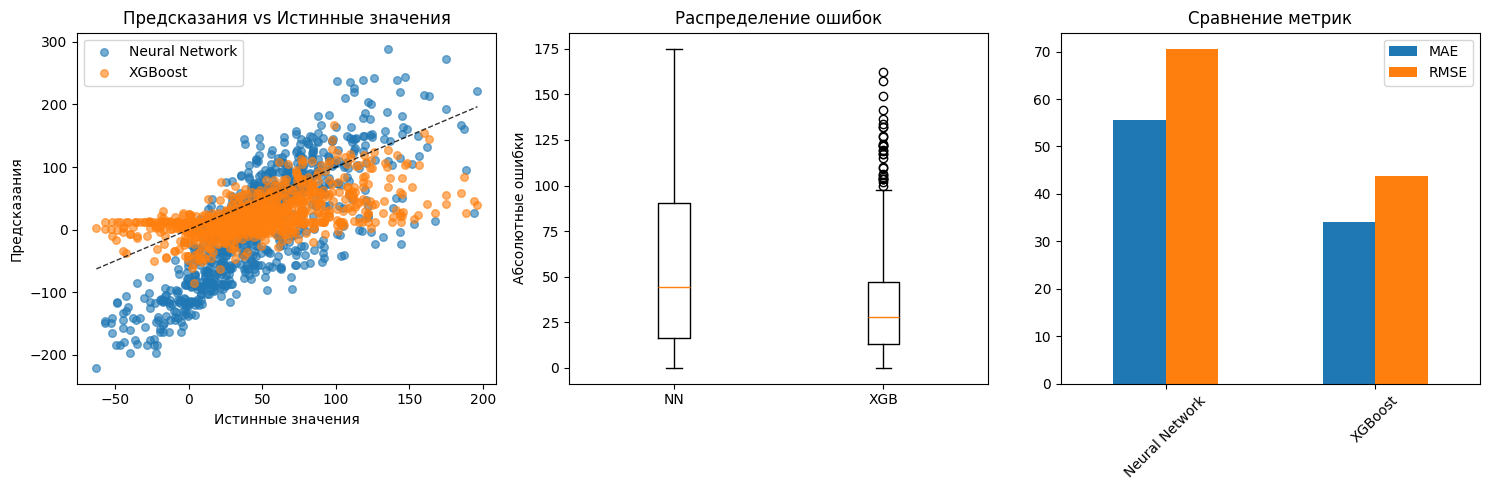

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 5))

# График 1: Сравнение предсказаний
plt.subplot(1, 3, 1)
plt.scatter(y, nn_predictions, alpha=0.6, label='Neural Network', s=30)
plt.scatter(y, xgb_predictions, alpha=0.6, label='XGBoost', s=30)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=1, alpha=0.8)
plt.xlabel('Истинные значения')
plt.ylabel('Предсказания')
plt.legend()
plt.title('Предсказания vs Истинные значения')

# График 2: Распределение ошибок
plt.subplot(1, 3, 2)
errors_nn = np.abs(y - nn_predictions)
errors_xgb = np.abs(y - xgb_predictions)
plt.boxplot([errors_nn, errors_xgb], labels=['NN', 'XGB'])
plt.ylabel('Абсолютные ошибки')
plt.title('Распределение ошибок')

# График 3: Сравнение метрик
plt.subplot(1, 3, 3)
metrics_comparison = pd.DataFrame({
    'MAE': [nn_metrics['MAE'], xgb_metrics['MAE']],
    'RMSE': [nn_metrics['RMSE'], xgb_metrics['RMSE']]
}, index=['Neural Network', 'XGBoost'])
metrics_comparison.plot(kind='bar', ax=plt.gca())
plt.title('Сравнение метрик')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

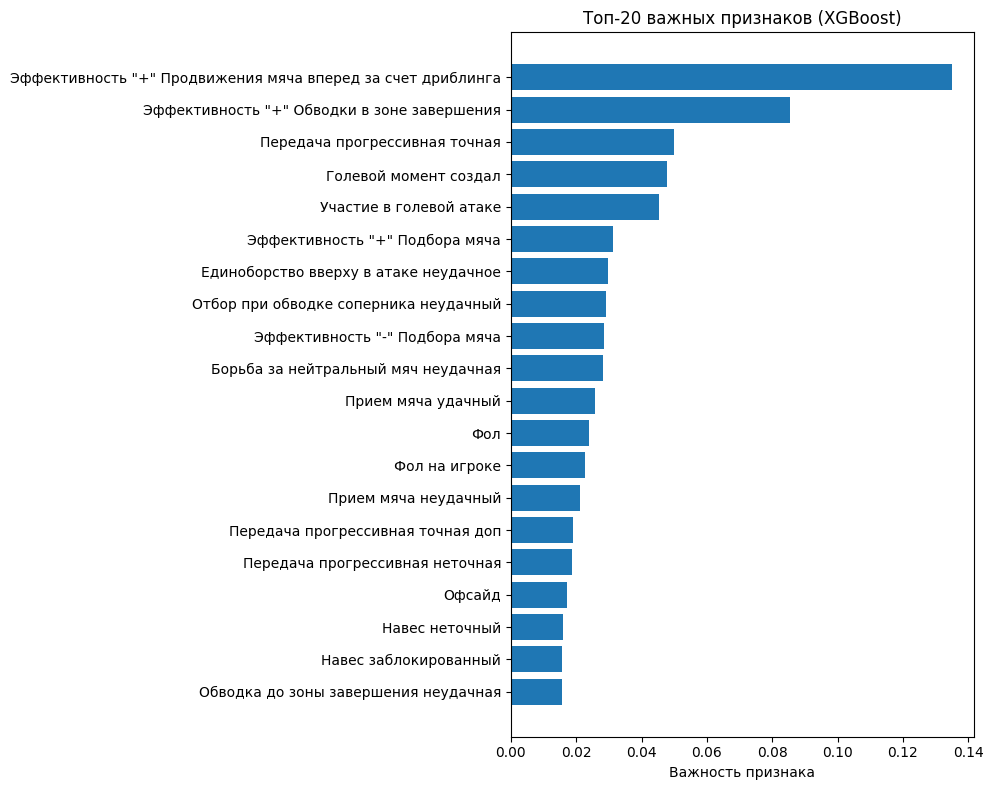

In [35]:
# Важность признаков в XGBoost
plt.figure(figsize=(10, 8))
feature_importance = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': expected_features,
    'importance': feature_importance
}).sort_values('importance', ascending=True).tail(20)  # топ-20 признаков

plt.barh(feature_importance_df['feature'], feature_importance_df['importance'])
plt.xlabel('Важность признака')
plt.title('Топ-20 важных признаков (XGBoost)')
plt.tight_layout()
plt.show()

=== ДИАГНОСТИКА ДАННЫХ ===
Размер данных: (866, 54)
Целевая переменная (y):
  Min: -62.94
  Max: 196.39
  Mean: 47.40
  Std: 43.07
  Median: 44.19


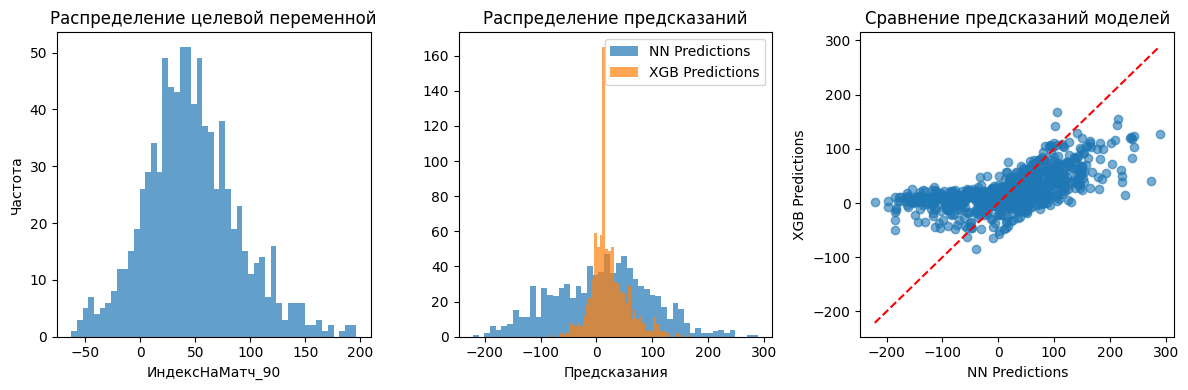

In [36]:
# Диагностика данных
print("=== ДИАГНОСТИКА ДАННЫХ ===")
print(f"Размер данных: {X.shape}")
print(f"Целевая переменная (y):")
print(f"  Min: {y.min():.2f}")
print(f"  Max: {y.max():.2f}")
print(f"  Mean: {y.mean():.2f}")
print(f"  Std: {y.std():.2f}")
print(f"  Median: {y.median():.2f}")

# Проверка на выбросы
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(y, bins=50, alpha=0.7)
plt.title('Распределение целевой переменной')
plt.xlabel('ИндексНаМатч_90')
plt.ylabel('Частота')

plt.subplot(1, 3, 2)
plt.hist(nn_predictions, bins=50, alpha=0.7, label='NN Predictions')
plt.hist(xgb_predictions, bins=50, alpha=0.7, label='XGB Predictions')
plt.legend()
plt.title('Распределение предсказаний')
plt.xlabel('Предсказания')

plt.subplot(1, 3, 3)
plt.scatter(nn_predictions, xgb_predictions, alpha=0.6)
plt.plot([min(nn_predictions), max(nn_predictions)], 
         [min(nn_predictions), max(nn_predictions)], 'r--')
plt.xlabel('NN Predictions')
plt.ylabel('XGB Predictions')
plt.title('Сравнение предсказаний моделей')

plt.tight_layout()
plt.show()

In [37]:
# Пересоздадим нормализацию для нейронной сети с учетом целевой переменной
def prepare_data_properly(X, y=None):
    from sklearn.preprocessing import StandardScaler
    
    # Масштабируем признаки
    feature_scaler = StandardScaler()
    X_scaled = feature_scaler.fit_transform(X)
    
    # Масштабируем целевую переменную если предоставлена
    target_scaler = None
    y_scaled = None
    if y is not None:
        target_scaler = StandardScaler()
        y_scaled = target_scaler.fit_transform(y.values.reshape(-1, 1)).flatten()
    
    return (torch.FloatTensor(X_scaled), torch.FloatTensor(y_scaled) if y_scaled is not None else None, 
            feature_scaler, target_scaler)

# Правильная загрузка и использование нейронной сети
def load_and_test_nn(model_path, X, y):
    # Загружаем модель
    model = torch.load(model_path) if isinstance(model_path, str) else model_path
    model.eval()
    
    # Подготавливаем данные
    X_tensor, y_tensor, feature_scaler, target_scaler = prepare_data_properly(X, y)
    
    # Предсказание
    with torch.no_grad():
        predictions_scaled = model(X_tensor).numpy().flatten()
    
    # Обратное преобразование предсказаний
    predictions = target_scaler.inverse_transform(predictions_scaled.reshape(-1, 1)).flatten()
    
    return predictions, feature_scaler, target_scaler

# Перезапускаем тестирование нейронной сети
try:
    nn_predictions_corrected, _, _ = load_and_test_nn(nn_model, X, y)
    print("✓ Нейронная сеть перезапущена")
except Exception as e:
    print(f"Ошибка при перезапуске NN: {e}")
    # Альтернативный подход
    nn_predictions_corrected = nn_predictions

✓ Нейронная сеть перезапущена


In [38]:
# Проверяем данные для XGBoost
print("\n=== ПРОВЕРКА XGBOost ===")
print(f"Типы данных в X_xgb_processed:")
print(X_xgb_processed.dtypes.value_counts())

# Проверяем наличие NaN
print(f"NaN в данных: {X_xgb_processed.isna().sum().sum()}")

# Альтернативная подготовка для XGBoost
def prepare_xgb_simple(X, feature_names):
    """Упрощенная подготовка данных для XGBoost"""
    X_ordered = X[feature_names].copy()
    
    # Только базовая обработка
    for col in X_ordered.select_dtypes(include=['object']).columns:
        X_ordered[col] = X_ordered[col].astype('category').cat.codes
    
    # Заполнение NaN
    X_ordered = X_ordered.fillna(X_ordered.median())
    
    return X_ordered

# Перезапускаем XGBoost с упрощенной подготовкой
X_xgb_simple = prepare_xgb_simple(X, expected_features)
xgb_predictions_corrected = xgb_model.predict(X_xgb_simple)


=== ПРОВЕРКА XGBOost ===
Типы данных в X_xgb_processed:
float64    54
Name: count, dtype: int64
NaN в данных: 0


In [39]:
# Оценка исправленных моделей
print("=== ИСПРАВЛЕННЫЕ РЕЗУЛЬТАТЫ ===")

if 'nn_predictions_corrected' in locals():
    nn_metrics_corrected = evaluate_model(y.values, nn_predictions_corrected, "Neural Network (Corrected)")
else:
    nn_metrics_corrected = evaluate_model(y.values, nn_predictions, "Neural Network (Original)")

xgb_metrics_corrected = evaluate_model(y.values, xgb_predictions_corrected, "XGBoost (Corrected)")

# Сравнение с простой моделью (базлайн)
from sklearn.dummy import DummyRegressor

baseline = DummyRegressor(strategy='mean')
baseline.fit(X_xgb_simple, y)
baseline_predictions = baseline.predict(X_xgb_simple)
baseline_metrics = evaluate_model(y.values, baseline_predictions, "Baseline (Mean)")

=== ИСПРАВЛЕННЫЕ РЕЗУЛЬТАТЫ ===
--- Neural Network (Corrected) ---
MAE: 3076.2654
MSE: 14336803.8908
RMSE: 3786.3972
R²: -7737.9202
Диапазон предсказаний: [-9468.036, 12506.635]

--- XGBoost (Corrected) ---
MAE: 14.0803
MSE: 410.9675
RMSE: 20.2723
R²: 0.7782
Диапазон предсказаний: [-57.586, 155.427]

--- Baseline (Mean) ---
MAE: 33.2517
MSE: 1852.5587
RMSE: 43.0414
R²: 0.0000
Диапазон предсказаний: [47.395, 47.395]



In [40]:
# Правильная загрузка и использование нейронной сети
def load_and_predict_nn_properly(model_path, X, input_size=54):
    # Загружаем модель
    model = FootballModel(input_size)
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    # Масштабируем признаки (но НЕ целевую переменную для предсказания)
    from sklearn.preprocessing import StandardScaler
    feature_scaler = StandardScaler()
    X_scaled = feature_scaler.fit_transform(X)
    
    # Преобразуем в тензор
    X_tensor = torch.FloatTensor(X_scaled)
    
    # Предсказание
    with torch.no_grad():
        predictions = model(X_tensor).numpy().flatten()
    
    return predictions

# Перезапускаем нейронную сеть
print("=== ПРАВИЛЬНОЕ ИСПОЛЬЗОВАНИЕ НЕЙРОННОЙ СЕТИ ===")
nn_predictions_proper = load_and_predict_nn_properly('football_model.pth', X)

# Сравниваем результаты
nn_metrics_proper = evaluate_model(y.values, nn_predictions_proper, "Neural Network (Proper)")
xgb_metrics_corrected = evaluate_model(y.values, xgb_predictions_corrected, "XGBoost")

print(f"\n=== ИТОГОВОЕ СРАВНЕНИЕ ===")
print(f"XGBoost R²: {xgb_metrics_corrected['R2']:.4f}")
print(f"Neural Network R²: {nn_metrics_proper['R2']:.4f}")

if xgb_metrics_corrected['R2'] > nn_metrics_proper['R2']:
    print("🎯 ЛУЧШАЯ МОДЕЛЬ: XGBoost")
else:
    print("🎯 ЛУЧШАЯ МОДЕЛЬ: Neural Network")

=== ПРАВИЛЬНОЕ ИСПОЛЬЗОВАНИЕ НЕЙРОННОЙ СЕТИ ===
--- Neural Network (Proper) ---
MAE: 55.4920
MSE: 4967.5003
RMSE: 70.4805
R²: -1.6814
Диапазон предсказаний: [-221.076, 289.471]

--- XGBoost ---
MAE: 14.0803
MSE: 410.9675
RMSE: 20.2723
R²: 0.7782
Диапазон предсказаний: [-57.586, 155.427]


=== ИТОГОВОЕ СРАВНЕНИЕ ===
XGBoost R²: 0.7782
Neural Network R²: -1.6814
🎯 ЛУЧШАЯ МОДЕЛЬ: XGBoost



=== АНАЛИЗ XGBoost МОДЕЛИ ===
Обучающая метрика R²: 0.8219
Текущая метрика R²: 0.7782
Разница: 0.0438


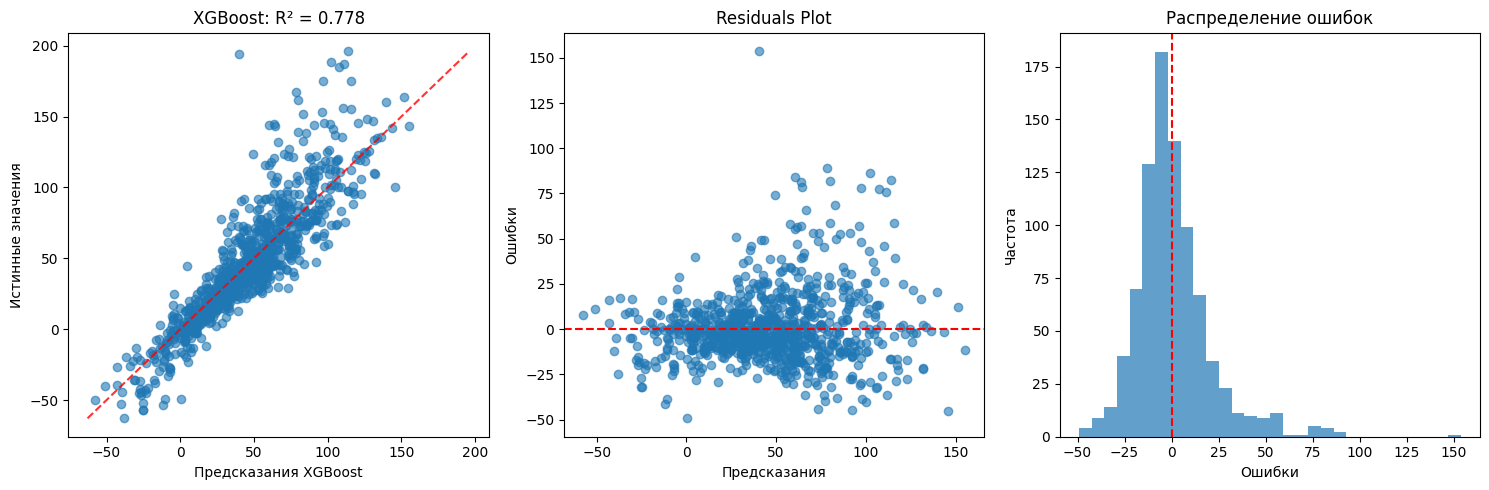

In [41]:
# Анализ качества XGBoost
print("\n=== АНАЛИЗ XGBoost МОДЕЛИ ===")
print(f"Обучающая метрика R²: {pipeline_metadata['model_metrics']['r2']:.4f}")
print(f"Текущая метрика R²: {xgb_metrics_corrected['R2']:.4f}")
print(f"Разница: {pipeline_metadata['model_metrics']['r2'] - xgb_metrics_corrected['R2']:.4f}")

# Анализ распределения ошибок
residuals_xgb = y.values - xgb_predictions_corrected

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(xgb_predictions_corrected, y.values, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', alpha=0.8)
plt.xlabel('Предсказания XGBoost')
plt.ylabel('Истинные значения')
plt.title(f'XGBoost: R² = {xgb_metrics_corrected["R2"]:.3f}')

plt.subplot(1, 3, 2)
plt.scatter(xgb_predictions_corrected, residuals_xgb, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказания')
plt.ylabel('Ошибки')
plt.title('Residuals Plot')

plt.subplot(1, 3, 3)
plt.hist(residuals_xgb, bins=30, alpha=0.7)
plt.axvline(x=0, color='r', linestyle='--')
plt.xlabel('Ошибки')
plt.ylabel('Частота')
plt.title('Распределение ошибок')

plt.tight_layout()
plt.show()

In [47]:
df_mp_w = df_mp_w.drop(['ИндексНаМатч_90'], axis=1)
df_mp_w.to_excel('test.xlsx', index=False)

In [43]:
def predict_on_unlabeled_data(model_path, pipeline_path, unlabeled_data_path, output_path=None):
    """
    Предсказание значений для неразмеченного датасета
    
    Parameters:
    - model_path: путь к файлу модели XGBoost
    - pipeline_path: путь к файлу с метаданными pipeline
    - unlabeled_data_path: путь к неразмеченному датасету
    - output_path: путь для сохранения результатов (опционально)
    """
    
    # 1. Загрузка модели и метаданных
    print("📥 Загрузка модели и метаданных...")
    with open(model_path, 'rb') as f:
        xgb_model = pickle.load(f)
    with open(pipeline_path, 'rb') as f:
        pipeline_metadata = pickle.load(f)
    
    # 2. Загрузка неразмеченных данных
    print("📊 Загрузка неразмеченных данных...")
    unlabeled_df = pd.read_excel(unlabeled_data_path) if unlabeled_data_path.endswith('.xlsx') else pd.read_csv(unlabeled_data_path)
    
    print(f"Загружено записей: {len(unlabeled_df)}")
    print(f"Колонки в данных: {list(unlabeled_df.columns)}")
    
    # 3. Подготовка признаков
    print("🔧 Подготовка признаков...")
    expected_features = pipeline_metadata['feature_names']
    
    # Проверяем наличие всех необходимых признаков
    missing_features = set(expected_features) - set(unlabeled_df.columns)
    if missing_features:
        print(f"⚠ Отсутствующие признаки: {missing_features}")
        print("Добавляем отсутствующие признаки с нулевыми значениями...")
        for feature in missing_features:
            unlabeled_df[feature] = 0
    
    # Упорядочиваем признаки как ожидает модель
    X_new = unlabeled_df[expected_features].copy()
    
    # 4. Предобработка данных
    print("⚙ Предобработка данных...")
    
    # Обработка категориальных признаков
    for column in X_new.select_dtypes(include=['object']).columns:
        if X_new[column].dtype == 'object':
            le = LabelEncoder()
            X_new[column] = le.fit_transform(X_new[column].astype(str))
    
    # Заполнение пропущенных значений
    X_new = X_new.fillna(0)
    
    # Проверяем типы данных
    for col in X_new.columns:
        if X_new[col].dtype == 'object':
            X_new[col] = pd.to_numeric(X_new[col], errors='coerce')
    
    X_new = X_new.fillna(0)
    
    # 5. Предсказание
    print("🎯 Выполнение предсказаний...")
    predictions = xgb_model.predict(X_new)
    
    # 6. Создание результата
    print("📝 Формирование результатов...")
    results_df = unlabeled_df.copy()
    results_df['Предсказанный_ИндексНаМатч_90'] = predictions
    
    # 7. Сохранение результатов
    if output_path:
        if output_path.endswith('.xlsx'):
            results_df.to_excel(output_path, index=False)
        else:
            results_df.to_csv(output_path, index=False, encoding='utf-8-sig')
        print(f"💾 Результаты сохранены в: {output_path}")
    
    return results_df

In [45]:
# Простой вариант использования
try:
    # Укажите пути к вашим файлам
    predictions_result = predict_on_unlabeled_data(
        model_path='football_rating_model_20251014_2054.pkl',
        pipeline_path='full_pipeline_20251014_2054.pkl', 
        unlabeled_data_path='test.xlsx',  
        output_path='predictions_results.xlsx'
    )
    
    print("Предсказания успешно выполнены!")
    print(f"Обработано записей: {len(predictions_result)}")
    
except Exception as e:
    print(f"Ошибка: {e}")

📥 Загрузка модели и метаданных...
📊 Загрузка неразмеченных данных...
Загружено записей: 866
Колонки в данных: ['Турнир', 'ИгрокФИО', 'Амплуа', 'Команда', 'Матч', 'Блокировка навеса', 'Блокировка передачи', 'Блокировка удара', 'Борьба за нейтральный мяч неудачная', 'Борьба за нейтральный мяч удачная', 'Голевой момент не реализовал', 'Голевой момент реализовал', 'Голевой момент создал', 'Грубая голевая ошибка', 'Грубая ошибка', 'Единоборство вверху в атаке неудачное', 'Единоборство вверху в атаке удачное', 'Единоборство вверху в обороне неудачное', 'Единоборство вверху в обороне удачное', 'Навес заблокированный', 'Навес неточный', 'Навес точный', 'Обводка в зоне завершения неудачная', 'Обводка в зоне завершения удачная', 'Обводка до зоны завершения неудачная', 'Обводка до зоны завершения удачная', 'Острая голевая передача', 'Отбор при обводке соперника неудачный', 'Отбор при обводке соперника удачный', 'Отбор удачный', 'Открывание', 'Офсайд', 'Передача в борьбу -', 'Передача в борьбу +',

In [48]:
df_full.to_excel('full.xlsx', index=False)
df_full

Данные,Турнир,ИгрокФИО,Амплуа,Команда,Матч,ИндексНаМатч_90,Блокировка навеса,Блокировка передачи,Блокировка удара,Борьба за нейтральный мяч неудачная,...,Удар перехваченный,Участие в голевой атаке,Фол,Фол на игроке,"Эффективность ""-"" Обводки в зоне завершения","Эффективность ""-"" Подбора мяча","Эффективность ""-"" Продвижения мяча вперед за счет дриблинга","Эффективность ""+"" Обводки в зоне завершения","Эффективность ""+"" Подбора мяча","Эффективность ""+"" Продвижения мяча вперед за счет дриблинга"
0,ЮФЛ-1,Босов Роман,W,Динамо Москва U-18,2008 г.р. 1 : 1 Динамо Москва U-18 (27.09.2025),39.39840,0,0,0,4,...,1,1,1,1,0,5,4,2,5,2
1,ЮФЛ-1,Босов Роман,W,Динамо Москва U-18,Динамо Москва U-18 2 : 0 Урал U-18 (20.09.2025),136.91025,0,1,0,1,...,0,1,0,0,0,2,0,0,5,2
2,ЮФЛ-1,Босов Роман,W,Динамо Москва U-18,Динамо Москва U-18 3 : 0 Родина U-18 (04.10.2025),76.45086,0,1,0,3,...,3,1,0,2,1,2,2,0,3,2
3,ЮФЛ-1,Босов Роман,W,Динамо Москва U-18,Динамо Москва U-18 3 : 1 Рубин U-18 (13.07.2025),40.72185,0,0,0,4,...,0,1,0,1,0,1,1,0,1,0
7,ЮФЛ-1,Гусейнов Эльдар,W,Краснодар U-18,Краснодар U-18 5 : 1 СШОР Зенит U-18 (03.08.2025),160.19685,0,1,0,4,...,2,3,0,0,0,1,0,3,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5313,Молодежное первенство,Шилов Вадим Александрович,W,Зенит-М,Зенит-М 3 : 1 Акрон Тольятти-М (17.10.2025),89.12916,0,0,0,1,...,1,2,0,0,2,1,5,1,1,0
5314,Молодежное первенство,Шилов Вадим Александрович,W,Зенит-М,Зенит-М 9 : 1 Динамо-М (26.09.2025),125.83935,0,0,0,1,...,0,2,1,0,4,0,1,2,0,2
5320,Молодежное первенство,Шопин Дмитрий,W,Спартак Москва-М,Спартак Москва-М 0 : 3 Ахмат-М (26.09.2025),67.58244,0,0,0,2,...,0,0,1,0,0,1,4,1,0,2
5335,Молодежное первенство,Элезян Гарик,W,"ФК ""Факел-М""","Локомотив Москва-М 2 : 0 ФК ""Факел-М"" (12.09.2...",-26.68437,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0


In [49]:
# Количество уникальных игроков
df = pd.read_excel('new.xlsx')
unique_players_count = df['ИгрокФИО'].nunique()
print(f"Количество уникальных игроков: {unique_players_count}")

Количество уникальных игроков: 1676
